# Function 7 — 6D ML Hyperparameter Tuning

**Objective:** maximise a model performance score (accuracy or F1)
**Surrogate:** GP with Matérn 5/2 kernel
**Acquisition:** Expected Improvement (EI), ξ = 0.01 — tight exploitation
**Y transform:** `log(Y + offset)`, offset = 1.0027

---

Six hyperparameters in [0, 1] — learning rate, regularisation, layers, units,
dropout, batch size — returning a performance score. One query per week, five
rounds completed.

**This was the most consistent function in the project: improvement in four of
five rounds, 1.365 → 2.195, a 61% gain.**

## Problem characteristics

| Property | Value | Implication |
|---|---|---|
| Dimensions | 6D | Getting large for a GP, but still workable |
| Dataset | 30 supplied, 35 total | Reasonable, though thin for six dimensions |
| Y range | 0.0027 to 2.195 | ~800×, and skewed — needs a transform |
| Shape | Most configs near zero, a few high | The transform's real job |
| Noise | Stochastic training noise | Random seeds, train/val splits, mini-batch sampling |

With six inputs the visualisation shows all C(6,2) = 15 pairwise slices, split
across three figures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import LeaveOneOut
from scipy.stats import norm
from itertools import combinations

import warnings
warnings.filterwarnings("ignore")

## 1. Data

Loaded from `../data/function_7.csv` rather than pasted inline.

In the original script `X` had grown to 36 rows while `Y_raw` had 35 values — a
pending round-6 query had been added before its result came back.
`model.fit(X, Y)` raises a shape-mismatch error in that state.

Keeping observations in one file with a `week` column makes that impossible.

In [2]:
# -----------------------------------------------------------------
#  DATA
# -----------------------------------------------------------------
df = pd.read_csv("../data/function_7.csv", float_precision="round_trip")

HYPERPARAMS = ["lr", "reg", "layers", "units", "dropout", "batch"]

X     = df[["x1", "x2", "x3", "x4", "x5", "x6"]].values
Y_raw = df["y"].values                 # performance score
week  = df["week"].values              # 0 = supplied, 1-5 = ours

print("Data shapes:")
print(f"  X     : {X.shape}")
print(f"  Y_raw : {Y_raw.shape}")
print(f"\nY_raw range : [{Y_raw.min():.6f},  {Y_raw.max():.6f}]")
print(f"Spread      : {Y_raw.max() / Y_raw.min():.0f}x")
print(f"Rounds present: {sorted(set(week))}")

readable = pd.DataFrame(X, columns=HYPERPARAMS)
readable["score"] = Y_raw
readable["week"]  = week
readable.tail(6)

Data shapes:
  X     : (35, 6)
  Y_raw : (35,)

Y_raw range : [0.002701,  2.194844]
Spread      : 812x
Rounds present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,lr,reg,layers,units,dropout,batch,score,week
29,0.476823,0.340942,0.014335,0.880140,0.998655,0.079664,0.095411,0
30,0.057860,0.451672,0.249000,0.242500,0.420428,0.730969,1.533717,1
31,0.085835,0.523081,0.258808,0.277611,0.344081,0.730301,1.644503,2
32,0.115356,0.489294,0.298109,0.303923,0.416870,0.711940,1.612579,3
33,0.099245,0.477025,0.233956,0.287922,0.384015,0.697804,1.743242,4
34,0.111111,0.333333,0.222222,0.333333,0.333333,0.777778,2.194844,5


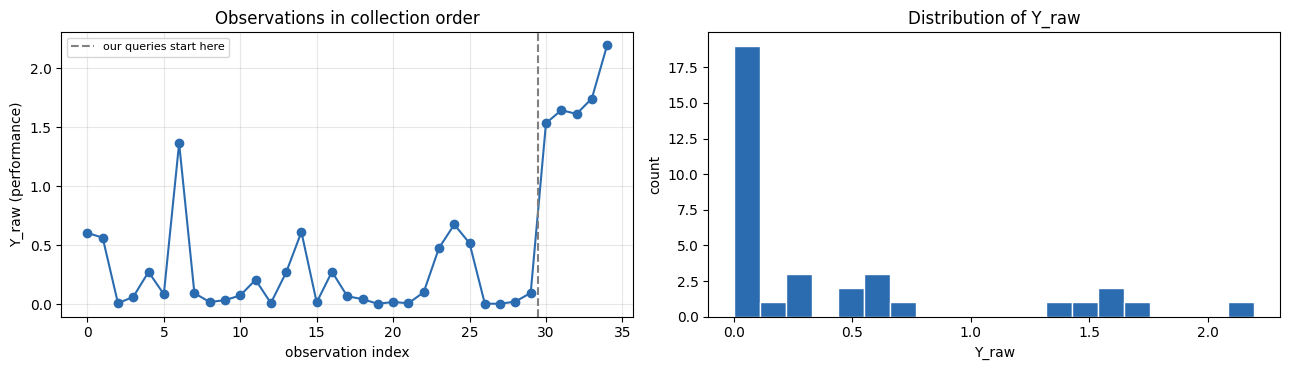

Observations scoring below 0.5 : 24 of 35
Observations scoring above 1.0 : 6 of 35


In [3]:
# The left plot is the important one here. Most configurations score near
# zero; only a handful reach above 1.0 - and all of those are recent.

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(Y_raw, "o-", color="#2b6cb0")
axes[0].axvline(np.sum(week == 0) - 0.5, color="grey", linestyle="--",
                label="our queries start here")
axes[0].set_xlabel("observation index")
axes[0].set_ylabel("Y_raw (performance)")
axes[0].set_title("Observations in collection order")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(Y_raw, bins=20, color="#2b6cb0", edgecolor="white")
axes[1].set_xlabel("Y_raw")
axes[1].set_ylabel("count")
axes[1].set_title("Distribution of Y_raw")

plt.tight_layout()
plt.show()

print(f"Observations scoring below 0.5 : {np.sum(Y_raw < 0.5)} of {len(Y_raw)}")
print(f"Observations scoring above 1.0 : {np.sum(Y_raw > 1.0)} of {len(Y_raw)}")

## 2. Y transform — log(Y + offset)

`Y_raw` spans 0.0027 to 2.195, roughly 800×. But the **shape** matters more
than the range.

Look at the histogram above: most configurations score near zero — these are
poor hyperparameter choices, and bad hyperparameters fail badly — while a
handful reach 1.3 and above.

Without the transform, the GP sees a dense mass of near-zero values with a few
scattered points far above them, and treats those few as outliers to be
smoothed away. It would be discarding precisely the observations worth learning
from, and over-fitting the near-zero cluster where nothing useful happens.

`offset = |min(Y_raw)| + 1 = 1.0027` shifts everything above zero so the log is
defined. Example mappings:

| Raw | Transformed | |
|---|---|---|
| 0.0027 | 0.005 | poor config |
| 0.0750 | 0.075 | |
| 0.6044 | 0.475 | |
| 1.3650 | 0.862 | |
| 2.1948 | 1.163 | current best |

The compressed range is uniform and GP-friendly, and the high performers are
now in proportion rather than looking anomalous.

In [4]:
# -----------------------------------------------------------------
#  Y TRANSFORM  —  log(Y_raw + offset)
# -----------------------------------------------------------------
offset = abs(Y_raw.min()) + 1.0        # = 1.0027
Y      = np.log(Y_raw + offset)

print(f"Offset applied      : {offset:.6f}")
print(f"Y_raw range         : [{Y_raw.min():.6f},  {Y_raw.max():.6f}]")
print(f"Y_transformed range : [{Y.min():.4f},  {Y.max():.4f}]")

# Show how the transform brings the high performers into proportion
order = np.argsort(Y_raw)
print("\nSample of the mapping, lowest to highest:")
for i in order[[0, 8, 18, 28, -2, -1]]:
    print(f"  {Y_raw[i]:8.4f}  ->  {Y[i]:.4f}")

Offset applied      : 1.002701


Y_raw range         : [0.002701,  2.194844]
Y_transformed range : [0.0054,  1.1624]

Sample of the mapping, lowest to highest:
    0.0027  ->  0.0054
    0.0182  ->  0.0207
    0.1005  ->  0.0982
    0.6751  ->  0.5175
    1.7432  ->  1.0101
    2.1948  ->  1.1624


## 3. Kernel

`ConstantKernel × Matérn(ν=5/2) + WhiteKernel`

| Component | Setting | Role |
|---|---|---|
| `ConstantKernel` | bounds (1e-3, 1e3) | Learns overall signal amplitude. |
| `Matérn(ν=2.5)` | — | Hyperparameter search surfaces are typically smooth with moderate complexity. Matérn 5/2 is the standard choice in AutoML Bayesian optimisation pipelines. |
| `length_scale` | 0.3, bounds **(0.05, 2.0)** | Lower bound raised from 0.01 — see the changelog. |
| `WhiteKernel` | 0.05, bounds (1e-6, 1.0) | ML evaluation scores carry stochastic noise: the same configuration run twice gives slightly different results from random seeds, train/val splits and mini-batch sampling. Lower than Function 4's 1.0 because this noise is moderate and consistent rather than systematic approximation error. |

### What changed at submission 6, and why

| Setting | Before | After | Reason |
|---|---|---|---|
| ξ | 0.05 | **0.01** | A clear new best at 2.195 — exploit tightly. |
| Grid | 10⁶ | **12⁶** | Finer resolution near the peak cluster, ~3M candidates. |
| `length_scale` lower bound | 0.01 | **0.05** | Prevents overfitting to the tight high-performing cluster. |
| `offset` | 1.0027 | unchanged | The minimum Y is still 0.0027. |
| `WhiteKernel` | 0.05 | unchanged | No evidence of increased noise. |

The original ξ = 0.05 was itself a judgement: three points had already found the
1.3–1.6 region, so the GP had a real signal to exploit and there was no need
for the strong exploration used on Function 4.

In [5]:
# -----------------------------------------------------------------
#  KERNEL
# -----------------------------------------------------------------
kernel = (
    ConstantKernel(
        constant_value=1.0,
        constant_value_bounds=(1e-3, 1e3),      # overall signal amplitude
    )
    * Matern(
        nu=2.5,                                 # standard for AutoML BO
        length_scale=0.3,
        length_scale_bounds=(0.05, 2.0),        # floor raised from 0.01
    )
    + WhiteKernel(
        noise_level=0.05,                       # stochastic training noise
        noise_level_bounds=(1e-6, 1.0),
    )
)

# -----------------------------------------------------------------
#  GP MODEL
# -----------------------------------------------------------------
xi = 0.01      # tight exploitation - a clear peak cluster exists

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=True,
    random_state=42,
)
model.fit(X, Y)

print(f"Optimised kernel:\n  {model.kernel_}")

fitted_ls    = model.kernel_.k1.k2.length_scale
fitted_noise = model.kernel_.k2.noise_level
print(f"\n  fitted length_scale : {fitted_ls:.4g}   (started at 0.3)")
print(f"  fitted noise_level  : {fitted_noise:.4g}   (started at 0.05)")

if fitted_ls <= 0.05 * 1.01:
    print("\n  NOTE: length_scale is at its LOWER BOUND of 0.05 - the model")
    print("  wants sharper variation than the raised floor permits.")

Optimised kernel:
  0.745**2 * Matern(length_scale=0.373, nu=2.5) + WhiteKernel(noise_level=1e-06)

  fitted length_scale : 0.3727   (started at 0.3)
  fitted noise_level  : 1e-06   (started at 0.05)


## 4. Does the model actually work?

Leave-one-out cross-validation: hide one observation, refit on the rest,
predict the hidden point, repeat for all 35.

Two measures are reported.

**RMSE** is the average size of the prediction error, in the units of this
function's target. It is an absolute measure — it says how wrong the model is,
not merely how it compares with an alternative — which makes it the more
interpretable of the two and the better choice when comparing different kinds
of model.

**R²** expresses the same error as a proportion of the variance: 1.0 is
perfect, 0.0 is no better than always predicting the average, and below 0.0 is
worse than that. It is unitless, so it travels between functions on different
scales, but a high value alone does not make a model appropriate.

Both are shown, along with the RMSE of simply predicting the mean, which is the
benchmark any useful model has to beat.

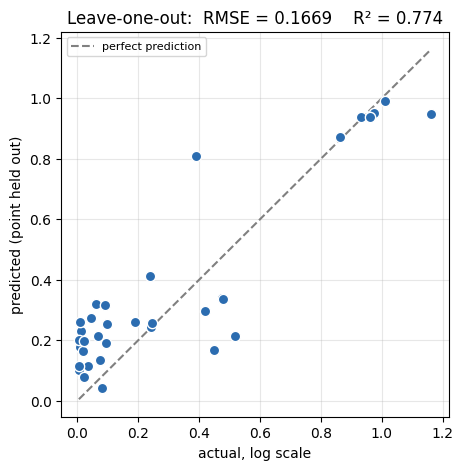

RMSE                       : 0.1669
RMSE if predicting the mean: 0.3514
Ratio                      : 0.475   (below 1 beats guessing)
R²                         : 0.774

The model predicts held-out points reasonably well, so its
suggestions are worth acting on.


In [6]:
# -----------------------------------------------------------------
#  LEAVE-ONE-OUT VALIDATION
# -----------------------------------------------------------------
predicted = np.empty(len(Y))

for train_idx, test_idx in LeaveOneOut().split(X):
    k = (ConstantKernel(1.0, (1e-3, 1e3))
         * Matern(nu=2.5, length_scale=0.3, length_scale_bounds=(0.05, 2.0))
         + WhiteKernel(0.05, (1e-6, 1.0)))
    g = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=3,
                                 normalize_y=True, random_state=42)
    g.fit(X[train_idx], Y[train_idx])
    predicted[test_idx] = g.predict(X[test_idx])

residuals = Y - predicted
r2 = 1 - (residuals ** 2).sum() / ((Y - Y.mean()) ** 2).sum()

# RMSE: the average size of the prediction error, in the units of the
# target. Unlike R2 it is an absolute measure, so it says how wrong the
# model is rather than only how it compares with guessing.
rmse = np.sqrt((residuals ** 2).mean())

# RMSE we would get by always predicting the mean - the benchmark any
# useful model has to beat.
baseline = np.sqrt(((Y - Y.mean()) ** 2).mean())
ratio    = rmse / baseline

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y, predicted, s=55, c="#2b6cb0", edgecolors="white", zorder=3)
lims = [min(Y.min(), predicted.min()), max(Y.max(), predicted.max())]
ax.plot(lims, lims, "--", color="grey", label="perfect prediction")
ax.set_xlabel("actual, log scale")
ax.set_ylabel("predicted (point held out)")
ax.set_title(f"Leave-one-out:  RMSE = {rmse:.4g}    R² = {r2:.3f}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print(f"RMSE                       : {rmse:.4g}")
print(f"RMSE if predicting the mean: {baseline:.4g}")
print(f"Ratio                      : {ratio:.3f}   (below 1 beats guessing)")
print(f"R²                         : {r2:.3f}")
if r2 >= 0.6:
    print("\nThe model predicts held-out points reasonably well, so its")
    print("suggestions are worth acting on.")
elif r2 >= 0.3:
    print("\nModerate. The model has learned real structure but is not precise.")
else:
    print("\nWeak. Treat the model's suggestions with caution.")

## 5. Prediction grid and Expected Improvement

EI(x) = (μ(x) − Y_best − ξ) · Φ(Z) + σ(x) · φ(Z)

**ξ = 0.01** — tight exploitation, lowered from 0.05 after round 5.

The grid is 12⁶ = **2,985,984** candidate points, the largest in the project.
Six dimensions need this many for even modest coverage — and even so, the
resolution is only about 0.09 per hyperparameter.

**A note on memory.** Calling `predict(return_std=True)` on 3 million points at
once asks scikit-learn to build a 3,000,000 × 35 intermediate matrix — roughly
800 MB in a single allocation, before any other working memory. On most
machines that either thrashes or fails outright.

Predicting in batches of 250,000 gives identical results with a fraction of the
peak memory, at the cost of a few extra seconds.

In [7]:
# -----------------------------------------------------------------
#  6D PREDICTION GRID  (12^6 = 2,985,984 candidates)
# -----------------------------------------------------------------
n_grid = 12
x_vals = np.linspace(0, 1, n_grid)
g      = np.meshgrid(*([x_vals] * 6), indexing="ij")
X_grid = np.column_stack([gi.ravel() for gi in g])

print(f"Grid size  : {len(X_grid):,} points")
print(f"Resolution : {1 / (n_grid - 1):.4f} per hyperparameter")


def predict_in_batches(model, points, batch_size=250_000):
    """Predict mean and std without allocating one enormous matrix.

    sklearn builds an (n_test x n_train) array internally. At 3 million test
    points that is ~800 MB in a single allocation. Batching gives the same
    answer with a fraction of the peak memory.
    """
    means, stds = [], []
    for start in range(0, len(points), batch_size):
        mu, sd = model.predict(points[start:start + batch_size],
                               return_std=True)
        means.append(mu)
        stds.append(sd)
    return np.concatenate(means), np.concatenate(stds)


post_mean, post_std = predict_in_batches(model, X_grid)
print(f"Predicted {len(post_mean):,} points.")


# -----------------------------------------------------------------
#  EXPECTED IMPROVEMENT
# -----------------------------------------------------------------
Y_best = Y.max()


def expected_improvement(mu, sigma, y_best, xi=0.01):
    improvement = mu - y_best - xi

    # Where sigma is effectively zero, Z would divide by zero. Set it to 0.0
    # and zero the resulting EI: a point with no uncertainty offers no
    # possibility of a surprise.
    Z  = np.where(sigma > 1e-9, improvement / sigma, 0.0)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-9] = 0.0
    return ei


ei_values = expected_improvement(post_mean, post_std, Y_best, xi)


# -----------------------------------------------------------------
#  NEXT SAMPLE
# -----------------------------------------------------------------
best_idx     = np.argmax(ei_values)
x_next       = X_grid[best_idx]
best_obs_idx = np.argmax(Y_raw)

print(f"\nCurrent best Y_raw    : {Y_raw[best_obs_idx]:.6f}")
print(f"  (log scale)         : {Y[best_obs_idx]:.6f}")
print(f"  found in round      : {week[best_obs_idx]}")
for name, v in zip(HYPERPARAMS, X[best_obs_idx]):
    print(f"    {name:<9}{v:.4f}")

print(f"\nNext hyperparameters  :")
for name, v in zip(HYPERPARAMS, x_next):
    print(f"    {name:<9}{v:.4f}")
print(f"\nMax EI value          : {ei_values[best_idx]:.6f}")
print(f"Distance from current best: "
      f"{np.linalg.norm(x_next - X[best_obs_idx]):.4f}")

Grid size  : 2,985,984 points
Resolution : 0.0909 per hyperparameter


Predicted 2,985,984 points.

Current best Y_raw    : 2.194844
  (log scale)         : 1.162384
  found in round      : 5
    lr       0.1111
    reg      0.3333
    layers   0.2222
    units    0.3333
    dropout  0.3333
    batch    0.7778

Next hyperparameters  :
    lr       0.0909
    reg      0.2727
    layers   0.2727
    units    0.2727
    dropout  0.2727
    batch    0.7273

Max EI value          : 0.013357
Distance from current best: 0.1286


## 6. Visualisation

Fifteen pairwise slices across three figures, three rows each (GP mean,
uncertainty, EI). In every panel the other four hyperparameters are held at the
next sample's values, shown in the panel title.

Hyperparameter names are used directly as axis labels — `lr`–`batch` rather
than `x1`–`x6` — so the panels are interpretable without a lookup.

The caveat on projected points bites hardest here. The white dots are **all**
observations projected onto the plane, and with four dimensions held fixed, a
dot can look adjacent to the star while being an entirely different
configuration. In six dimensions almost everything is far from everything.

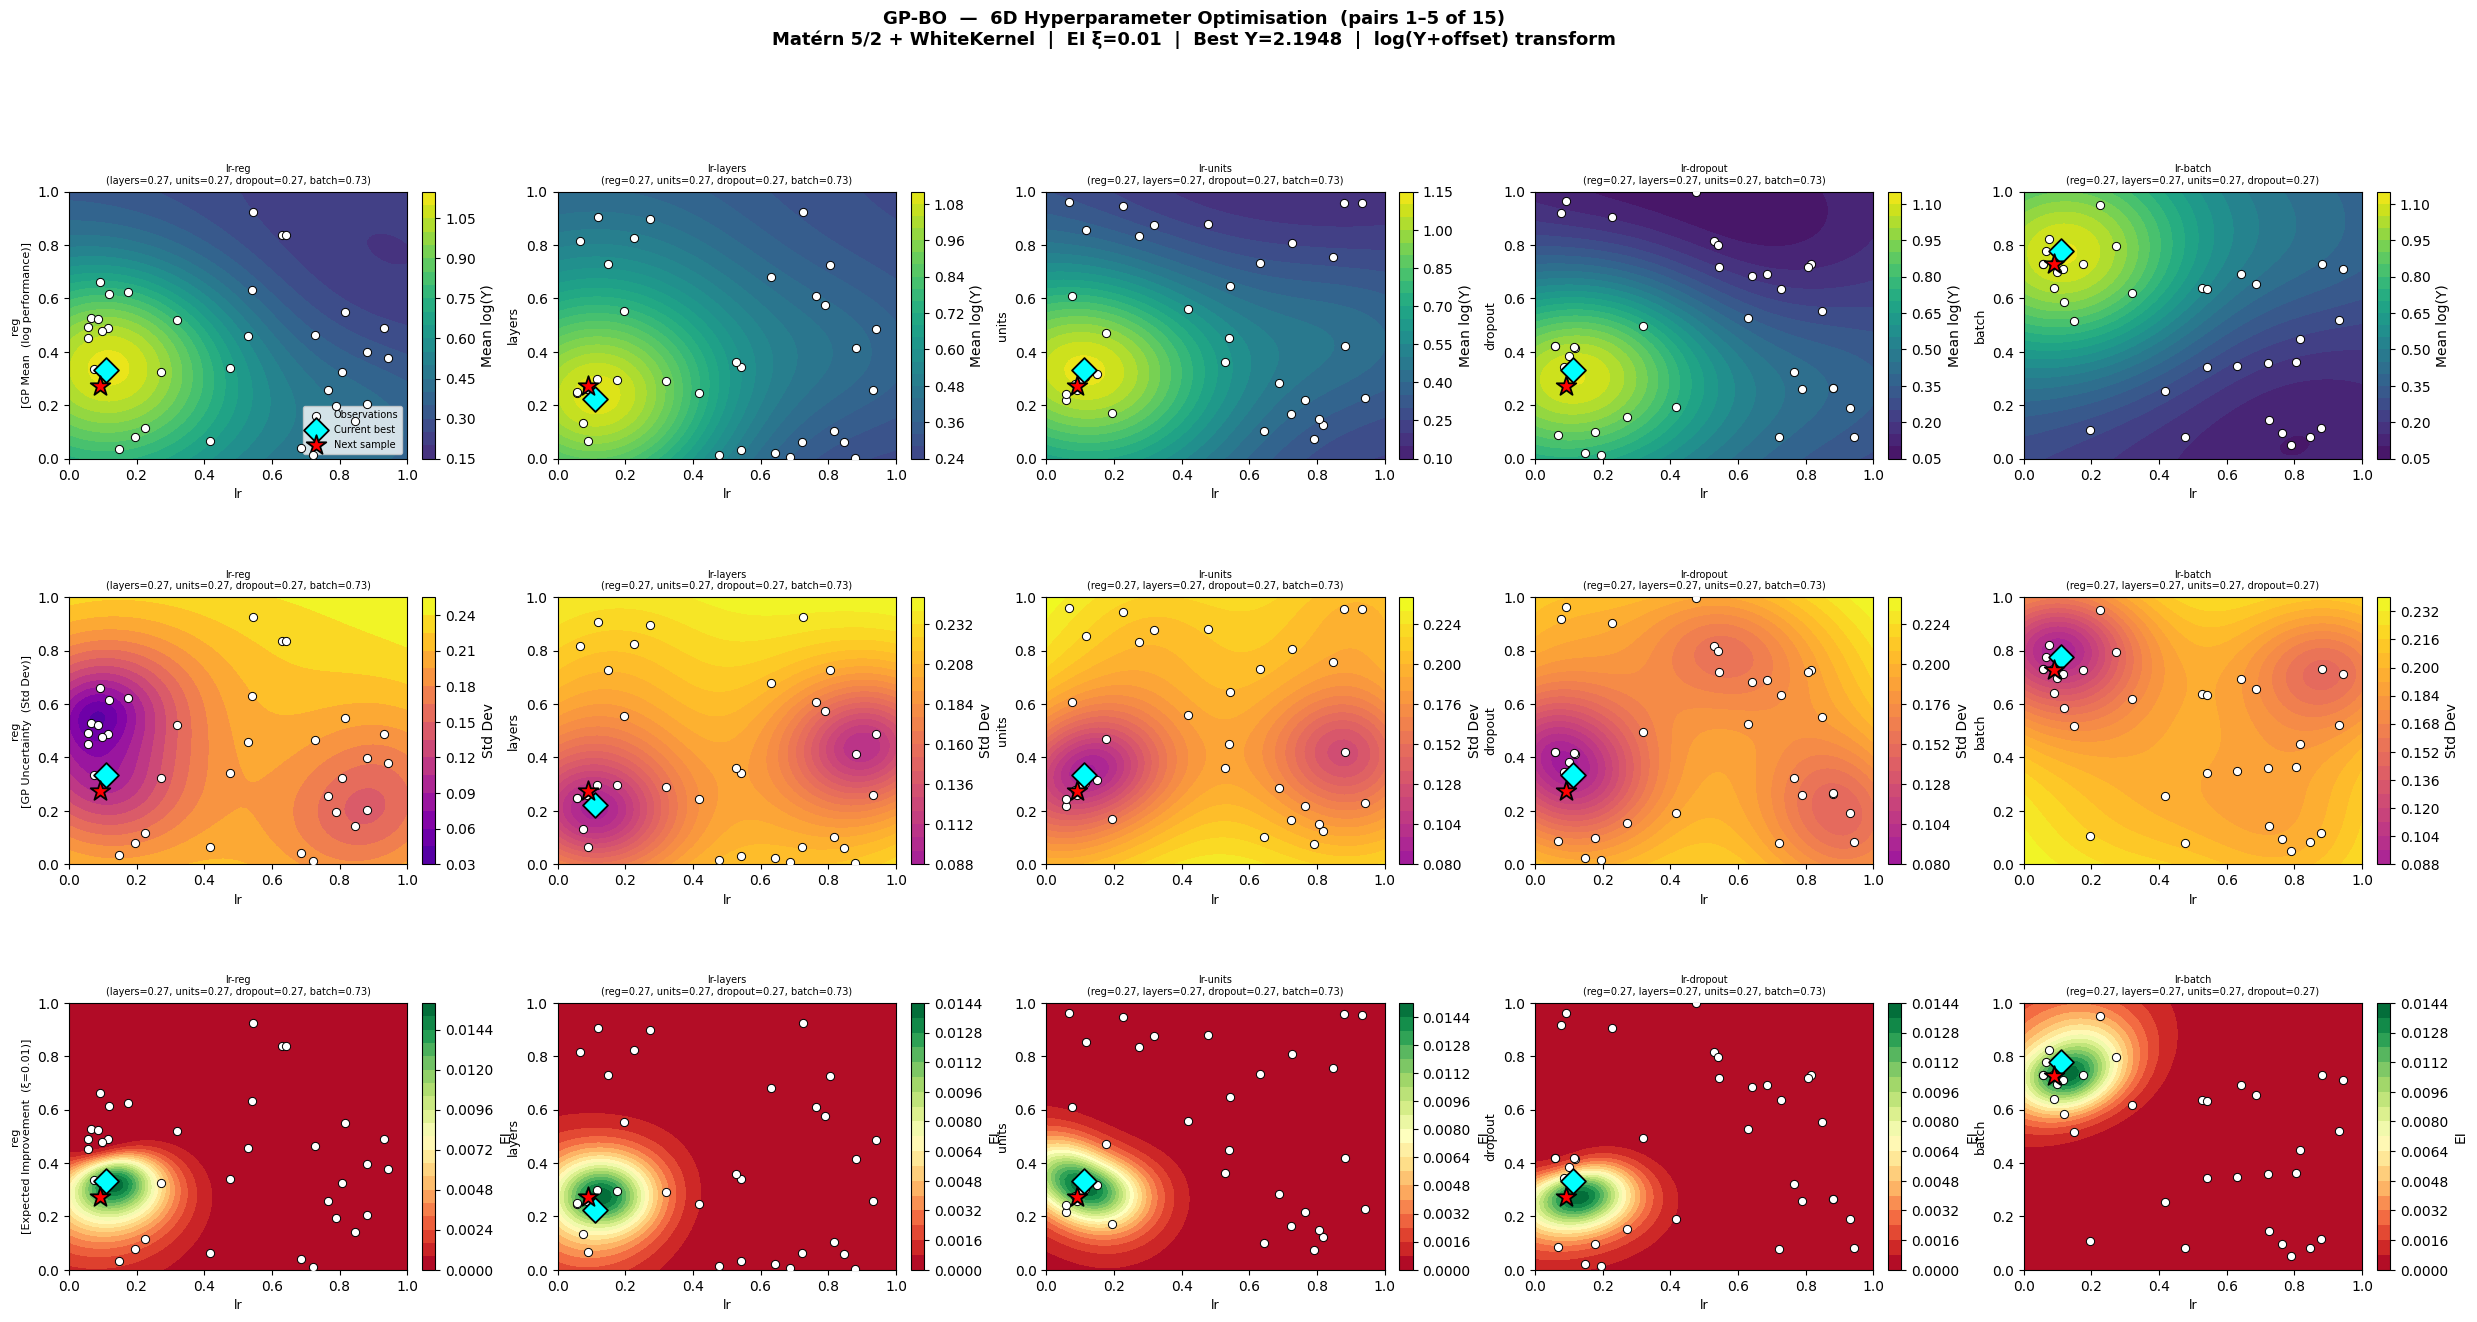

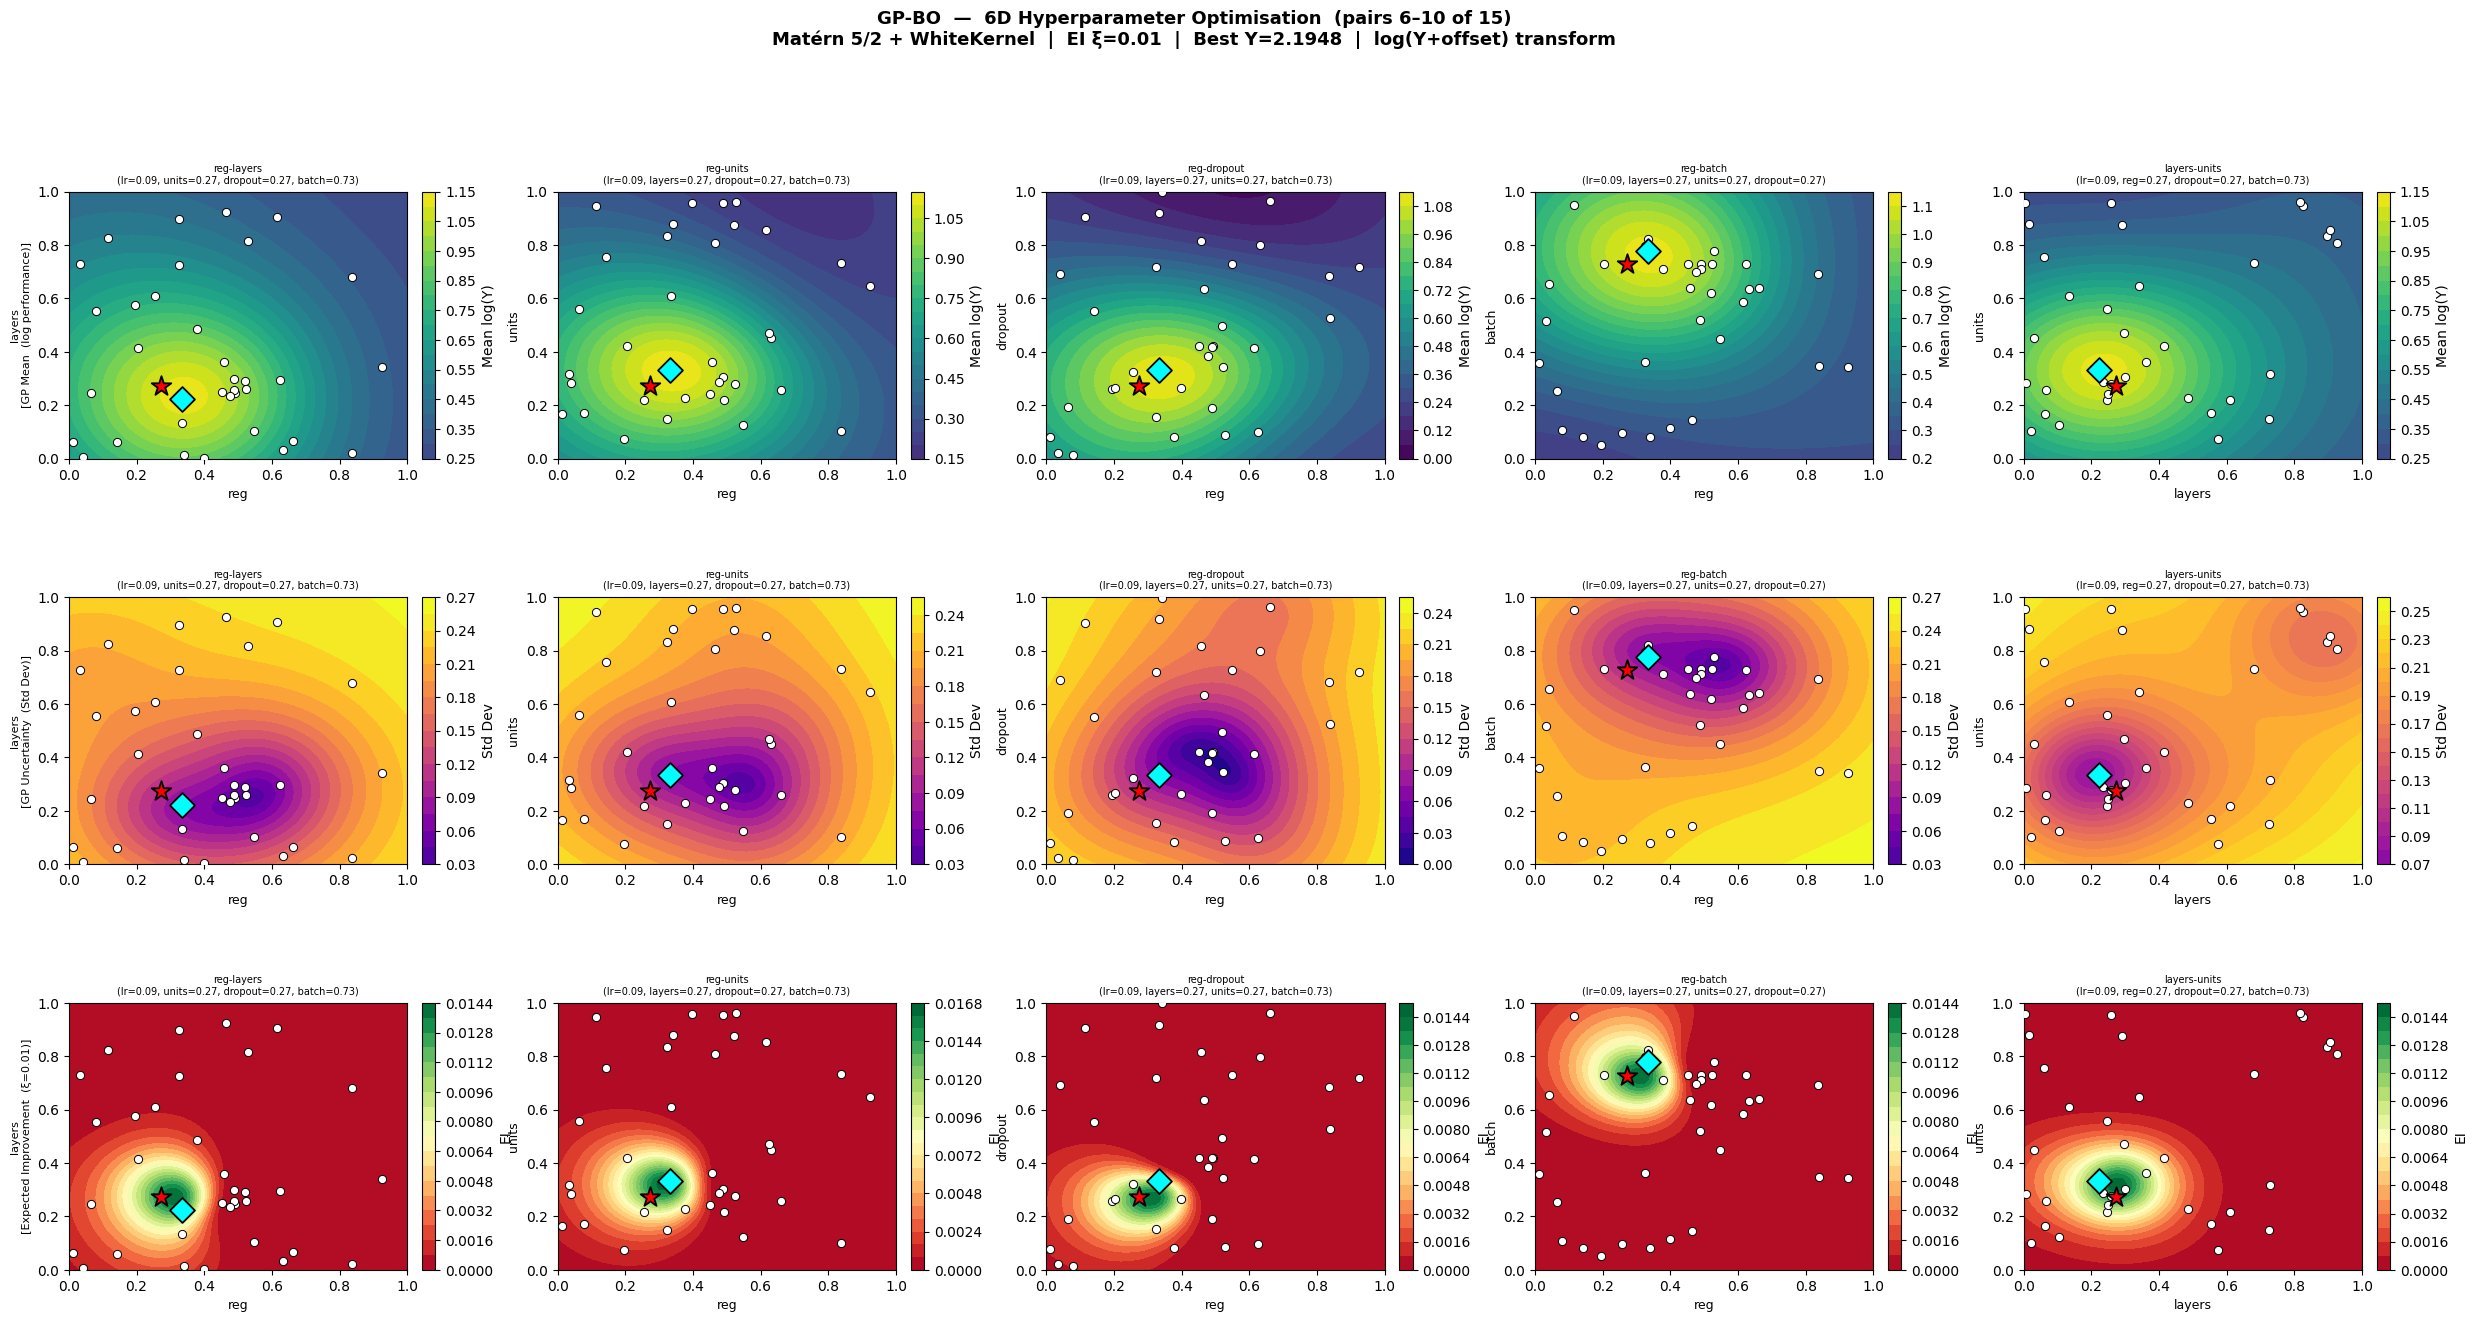

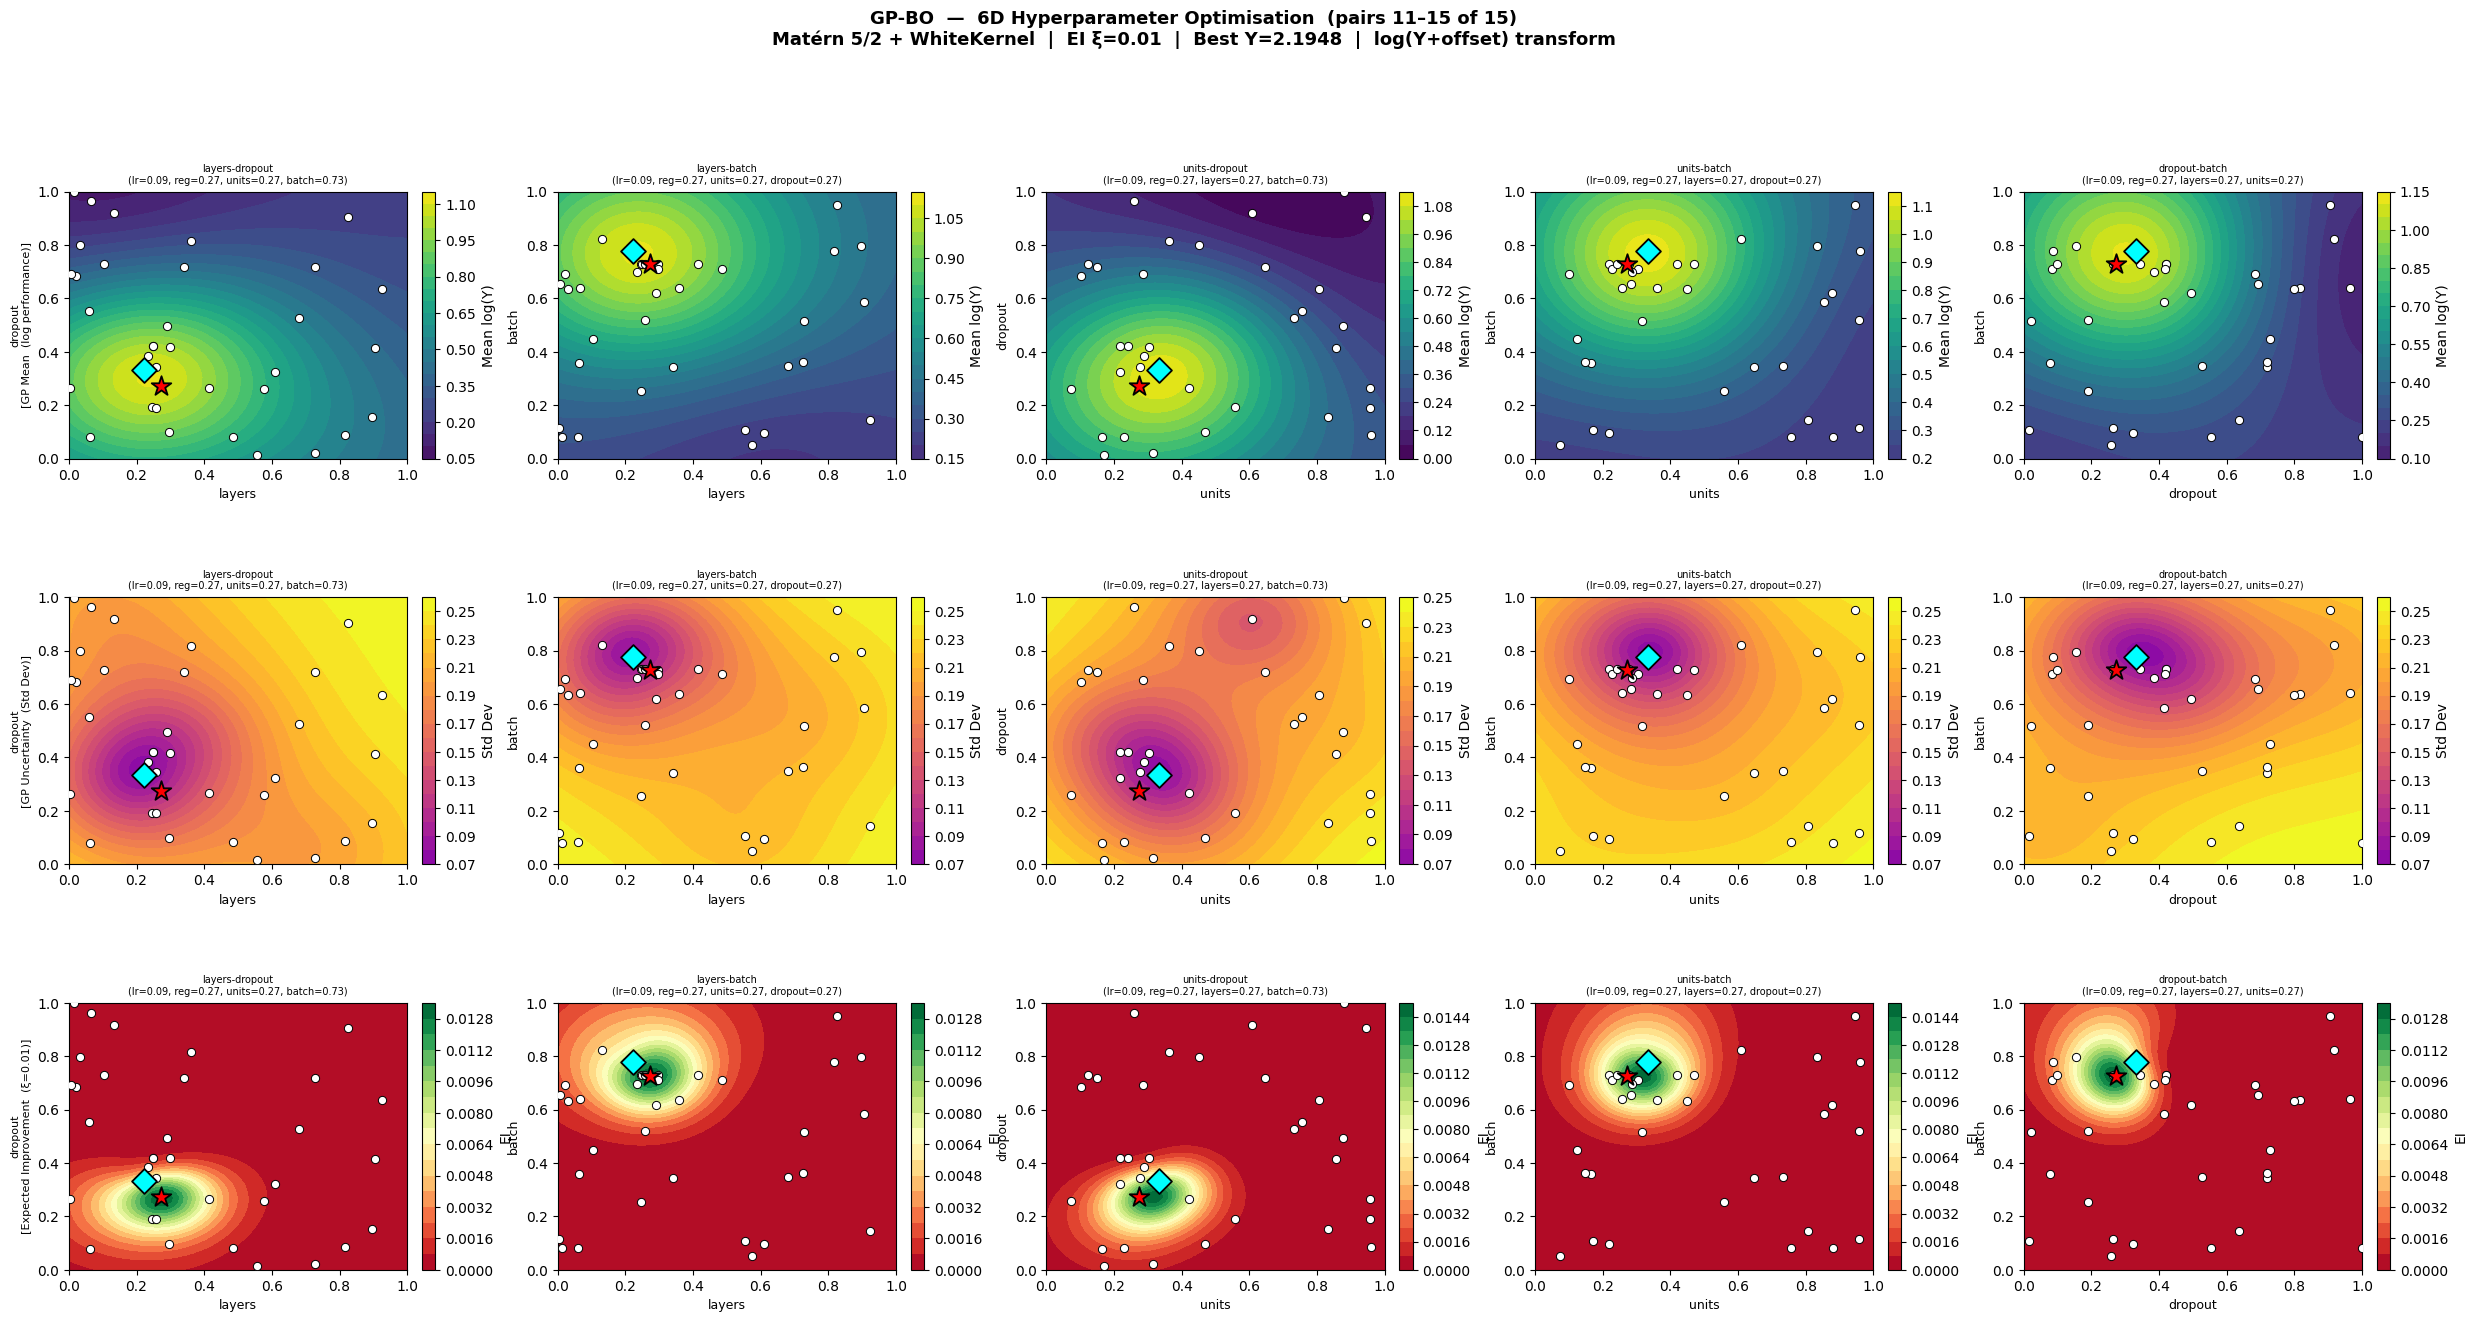

In [8]:
# -----------------------------------------------------------------
#  VISUALISATION — C(6,2) = 15 pairwise slices, 3 figures
# -----------------------------------------------------------------
n_slice    = 60
s_vals     = np.linspace(0, 1, n_slice)
S1, S2     = np.meshgrid(s_vals, s_vals)
axis_names = HYPERPARAMS
PAIRS      = list(combinations(range(6), 2))       # 15 pairs

ROW_LABELS = [
    "GP Mean  (log performance)",
    "GP Uncertainty  (Std Dev)",
    f"Expected Improvement  (\u03be={xi})",
]

for fig_idx, pair_slice in enumerate([PAIRS[:5], PAIRS[5:10], PAIRS[10:]]):
    n_cols = len(pair_slice)
    fig = plt.figure(figsize=(6 * n_cols, 14))
    fig.suptitle(
        f"GP-BO  —  6D Hyperparameter Optimisation  "
        f"(pairs {fig_idx*5+1}\u2013{fig_idx*5+n_cols} of 15)\n"
        f"Mat\u00e9rn 5/2 + WhiteKernel  |  EI \u03be={xi}  |  "
        f"Best Y={Y_raw[best_obs_idx]:.4f}  |  log(Y+offset) transform",
        fontsize=13, fontweight="bold", y=1.01,
    )
    gs = gridspec.GridSpec(3, n_cols, figure=fig, hspace=0.52, wspace=0.32)

    for col, (ax_a, ax_b) in enumerate(pair_slice):

        fixed_axes = [i for i in range(6) if i not in (ax_a, ax_b)]
        title_fix  = ", ".join(
            f"{axis_names[i]}={x_next[i]:.2f}" for i in fixed_axes
        )

        for row in range(3):
            ax = fig.add_subplot(gs[row, col])

            grid          = np.tile(x_next, (n_slice ** 2, 1))
            grid[:, ax_a] = S1.ravel()
            grid[:, ax_b] = S2.ravel()

            mu_sl, std_sl = model.predict(grid, return_std=True)
            ei_sl = expected_improvement(mu_sl, std_sl, Y_best, xi)

            if row == 0:
                Z, cmap    = mu_sl.reshape(n_slice, n_slice), "viridis"
                vmin, vmax = Y.min(), Y.max()
                cb_label   = "Mean log(Y)"
            elif row == 1:
                Z, cmap    = std_sl.reshape(n_slice, n_slice), "plasma"
                vmin, vmax = 0, std_sl.max()
                cb_label   = "Std Dev"
            else:
                Z, cmap    = ei_sl.reshape(n_slice, n_slice), "RdYlGn"
                vmin, vmax = 0, max(ei_sl.max(), 1e-9)
                cb_label   = "EI"

            cf = ax.contourf(S1, S2, Z, levels=20, cmap=cmap,
                             vmin=vmin, vmax=vmax)

            ax.scatter(X[:, ax_a], X[:, ax_b], c="white", s=35,
                       edgecolors="black", linewidths=0.7, zorder=10,
                       label="Observations")
            ax.scatter(X[best_obs_idx, ax_a], X[best_obs_idx, ax_b],
                       c="cyan", s=160, marker="D", edgecolors="black",
                       linewidths=1.3, zorder=11, label="Current best")
            ax.scatter(x_next[ax_a], x_next[ax_b], c="red", s=220,
                       marker="*", edgecolors="black", linewidths=1.3,
                       zorder=12, label="Next sample")

            ax.set_xlabel(axis_names[ax_a], fontsize=9)
            ax.set_title(f"{axis_names[ax_a]}-{axis_names[ax_b]}"
                         f"\n({title_fix})", fontsize=7)

            if col == 0:
                ax.set_ylabel(f"{axis_names[ax_b]}\n[{ROW_LABELS[row]}]",
                              fontsize=8)
            else:
                ax.set_ylabel(axis_names[ax_b], fontsize=9)

            plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label=cb_label)

            if row == 0 and col == 0 and fig_idx == 0:
                ax.legend(fontsize=7, loc="lower right")

    plt.show()

## 7. Round-by-round review

**The most consistent function in the project: improvement in four of five
rounds, 1.365 → 2.195, a 61% gain.**

| Round | lr | reg | layers | units | dropout | batch | Y | Improved |
|---|---|---|---|---|---|---|---|---|
| 1 | 0.058 | 0.452 | 0.249 | 0.243 | 0.420 | 0.731 | 1.534 | **yes** |
| 2 | 0.086 | 0.523 | 0.259 | 0.278 | 0.344 | 0.730 | 1.645 | **yes** |
| 3 | 0.115 | 0.489 | 0.298 | 0.304 | 0.417 | 0.712 | 1.613 | no |
| 4 | 0.099 | 0.477 | 0.234 | 0.288 | 0.384 | 0.698 | 1.743 | **yes** |
| 5 | 0.111 | 0.333 | 0.222 | 0.333 | 0.333 | 0.778 | 2.195 | **yes** |

### Why this one worked

Every query sits in the same narrow region, and each moved a short distance
from the last. That is what a successful search looks like — not a survey of
the space, but a sequence of small steps refining one area.

The pattern across the top five observations is stable:

| Hyperparameter | Range in top 5 | Reading |
|---|---|---|
| lr | 0.06–0.12 | very low |
| reg | 0.33–0.52 | low to moderate |
| layers | 0.22–0.30 | low |
| units | 0.24–0.33 | low |
| dropout | 0.33–0.42 | low to moderate |
| batch | 0.70–0.78 | high |

**This is consistent with known practice for stable ML training:** a low
learning rate with a large batch size, a shallow network, and moderate
regularisation. That the optimiser converged on a configuration matching
established heuristics is a useful sanity check — it suggests the surface is
real rather than an artefact of the model.

### The transform earned its place here

Function 7 is the clearest case in the project where the transform did
identifiable work. **Twenty-four of the thirty-five observations score below
0.5**, and only six reach above 1.0. Untransformed, the GP would treat that
handful as outliers against the near-zero mass and smooth them away —
discarding the only observations that matter. Every improvement above came from
that cluster.

### Two cautions

1. **Round 3 went backwards** (1.613 against the incumbent 1.645), and round 5
   jumped to a noticeably different configuration — reg dropped from 0.477 to
   0.333 — rather than refining round 4. With stochastic evaluation noise, some
   of the variation between these five results is measurement rather than
   surface.

2. **This trajectory was cut short.** The largest single gain came in round 5,
   the final round. A search still producing its biggest improvement at the end
   has not converged.

In [9]:
# -----------------------------------------------------------------
#  ROUND-BY-ROUND LOG
# -----------------------------------------------------------------
rows = []
for r in range(1, week.max() + 1):
    i = np.where(week == r)[0][0]
    prev_best = Y_raw[week < r].max()
    row = {"round": r}
    for name, v in zip(HYPERPARAMS, X[i]):
        row[name] = round(float(v), 3)
    row["Y"]          = round(float(Y_raw[i]), 4)
    row["best after"] = round(float(Y_raw[week <= r].max()), 4)
    row["improved"]   = "yes" if Y_raw[i] > prev_best else "no"
    rows.append(row)

pd.DataFrame(rows)

,round,lr,reg,layers,units,dropout,batch,Y,best after,improved
0,1,0.058,0.452,0.249,0.242,0.420,0.731,1.5337,1.5337,yes
1,2,0.086,0.523,0.259,0.278,0.344,0.730,1.6445,1.6445,yes
2,3,0.115,0.489,0.298,0.304,0.417,0.712,1.6126,1.6445,no
3,4,0.099,0.477,0.234,0.288,0.384,0.698,1.7432,1.7432,yes
4,5,0.111,0.333,0.222,0.333,0.333,0.778,2.1948,2.1948,yes


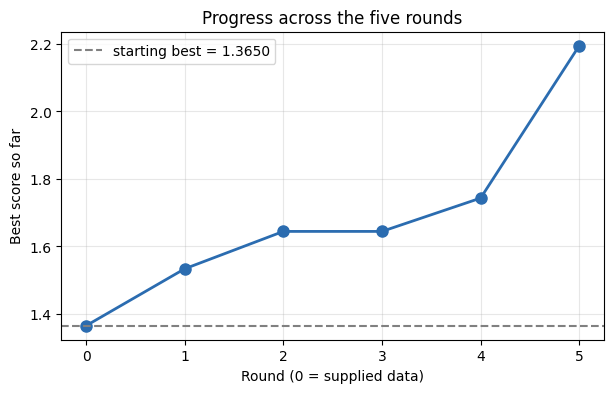

Gain per round: +0.169 +0.111 +0.000 +0.099 +0.452


In [10]:
# Best score so far, after each round. Four rises in five rounds - the most
# consistent trajectory in the project - and the steepest rise is the last.

rounds      = np.arange(week.max() + 1)
best_so_far = [Y_raw[week <= r].max() for r in rounds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, best_so_far, "o-", linewidth=2, markersize=8, color="#2b6cb0")
ax.axhline(best_so_far[0], color="grey", linestyle="--",
           label=f"starting best = {best_so_far[0]:.4f}")
ax.set_xlabel("Round (0 = supplied data)")
ax.set_ylabel("Best score so far")
ax.set_title("Progress across the five rounds")
ax.set_xticks(rounds)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("Gain per round:", " ".join(f"{g:+.3f}" for g in np.diff(best_so_far)))

In [11]:
# -----------------------------------------------------------------
#  SUMMARY
# -----------------------------------------------------------------
start_best = Y_raw[week == 0].max()
labels = ["(very low)", "(low-moderate)", "(low)", "(low)",
          "(low-moderate)", "(high)"]

print("=" * 65)
print("Summary — ML Hyperparameter Optimisation 6D")
print("=" * 65)
print(f"  Total observations        : {len(X)}")
print(f"  Best Y_raw so far         : {Y_raw[best_obs_idx]:.6f}")
print(f"  Found in round            : {week[best_obs_idx]}")
print(f"  Best hyperparameters      :")
for name, v, lab in zip(HYPERPARAMS, X[best_obs_idx], labels):
    print(f"    {name:<9}{v:.4f}  {lab}")
print(f"  Starting best             : {start_best:.6f}")
print(f"  Improvement               : "
      f"{(Y_raw.max() - start_best) / start_best * 100:+.1f}%")
print(f"  Y transform               : log(Y_raw + {offset:.4f})")
print(f"  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel")
print(f"  Fitted length_scale       : {fitted_ls:.4g}")
print(f"  Fitted noise_level        : {fitted_noise:.4g}")
print(f"  Model quality (R2)        : {r2:.3f}")
print(f"  EI xi parameter           : {xi}  (tight exploitation)")
print(f"  Grid resolution           : {n_grid}^6 = {n_grid**6:,} points")
print(f"  Next hyperparameters      :")
for name, v in zip(HYPERPARAMS, x_next):
    print(f"    {name:<9}{v:.4f}")
print(f"  Max EI value              : {ei_values[best_idx]:.6f}")
print("=" * 65)

Summary — ML Hyperparameter Optimisation 6D
  Total observations        : 35
  Best Y_raw so far         : 2.194844
  Found in round            : 5
  Best hyperparameters      :
    lr       0.1111  (very low)
    reg      0.3333  (low-moderate)
    layers   0.2222  (low)
    units    0.3333  (low)
    dropout  0.3333  (low-moderate)
    batch    0.7778  (high)
  Starting best             : 1.364968
  Improvement               : +60.8%
  Y transform               : log(Y_raw + 1.0027)
  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel
  Fitted length_scale       : 0.3727
  Fitted noise_level        : 1e-06
  Model quality (R2)        : 0.774
  EI xi parameter           : 0.01  (tight exploitation)
  Grid resolution           : 12^6 = 2,985,984 points
  Next hyperparameters      :
    lr       0.0909
    reg      0.2727
    layers   0.2727
    units    0.2727
    dropout  0.2727
    batch    0.7273
  Max EI value              : 0.013357


---

See `MODEL_CARD.md` for how this function compares with the other seven and for
the full list of assumptions and limitations, and `DATASHEET.md` for known gaps
and biases in the data.